In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(123)
m = 200
X = 2 * rng.random((m, 1))
y = 4 + 3 * X + rng.standard_normal((m, 1))

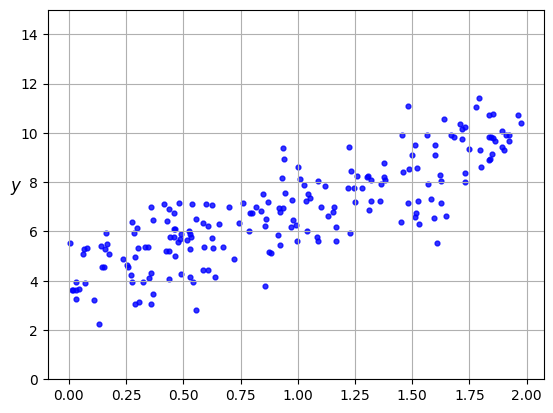

In [34]:
plt.ylim(0, 15)
plt.grid()
plt.ylabel('y', loc='center', rotation = 'horizontal', style = 'italic', fontsize=12)
plt.scatter(X, y, s=12, c='b', alpha=0.8);

In [35]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [36]:
theta_best

array([[4.03608087],
       [2.9232143 ]])

In [39]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
y_predict

array([[4.03608087],
       [9.88250946]])

In [40]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.03608087]), array([[2.9232143]]))

In [41]:
lin_reg.predict(X_new)

array([[4.03608087],
       [9.88250946]])

### Batch Gradient Descent

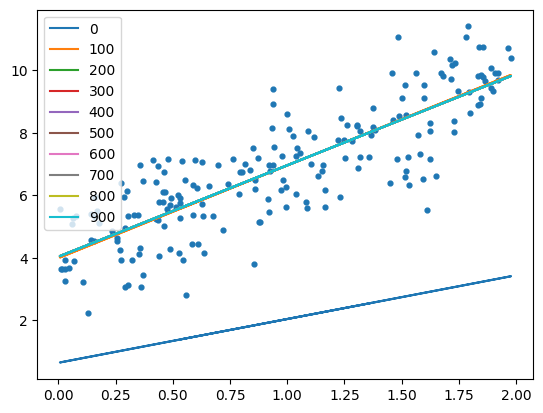

In [77]:
eta = 0.1
n_epochs = 1000
m = len(X_b)
thetas = []

rng = np.random.default_rng(123)
theta = rng.standard_normal((2, 1))

for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients
    thetas.append(theta)

plt.scatter(X, y, s=12);
for n in range(0, len(thetas), 100):
    theta_n = thetas[n]
    y_pred = X_b @ theta_n
    plt.plot(X, y_pred, label=f'{n}')
plt.legend();

In [78]:
sorted_idx = np.argsort(X[:, 0])
X = X[sorted_idx]
y = y[sorted_idx]
X_b = X_b[sorted_idx]

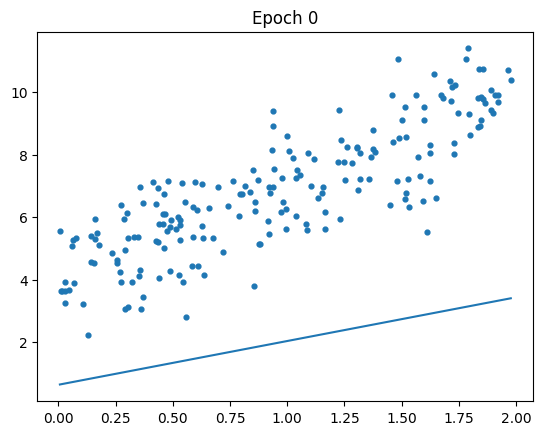

In [84]:
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots()

ax.scatter(X, y, s=12)
line, = ax.plot(X, X_b @ thetas[0])
color='red'

def update(frame):
    theta = thetas[frame]
    y_pred = X_b @ theta
    line.set_ydata(y_pred)
    ax.set_title(f'Epoch {frame}')
    return line,

anim = FuncAnimation(
    fig, 
    update,
    frames=len(thetas),
    interval=20,
    blit=True
)

plt.show()

In [85]:
anim.save('gradient_descent.gif', writer='pillow', fps=30)